# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

df = pd.read_csv("data/IT_customer_churn.csv")
print(df.head())

   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              Yes          No  

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [3]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isna().sum())

11


In [4]:
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)



In [5]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


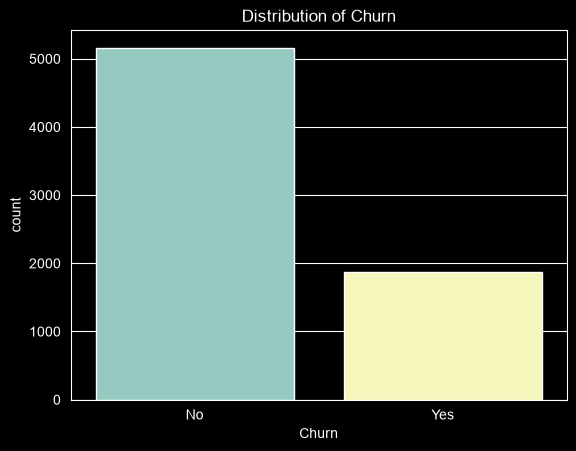

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Churn', hue='Churn')
plt.title('Distribution of Churn')
plt.show()

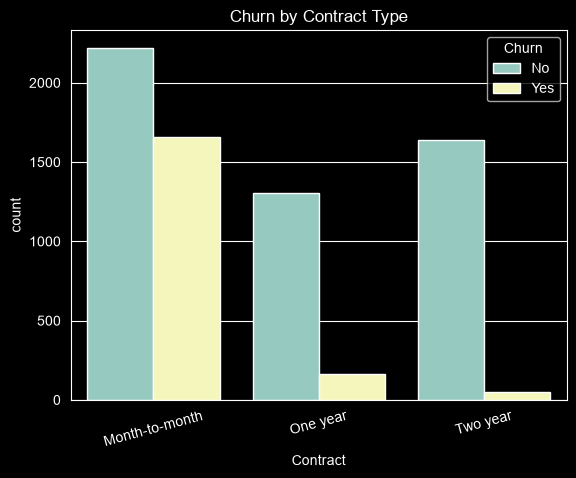

In [7]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

In [8]:
# جدا کردن X و y
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# ستون‌های عددی و دسته‌ای
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print(numeric_cols)
print(categorical_cols)

['tenure', 'MonthlyCharges', 'TotalCharges']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [9]:
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), categorical_cols)
])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(X_train_transformed.shape, X_test_transformed.shape)

(5625, 40) (1407, 40)


In [11]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_transformed, y_train)

y_pred_log = log_model.predict(X_test_transformed)
y_proba_log = log_model.predict_proba(X_test_transformed)[:, 1]

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.8348962836036465


In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_transformed, y_train)

print("قبل از SMOTE:", y_train.value_counts().to_dict())
print("بعد از SMOTE:", y_train_sm.value_counts().to_dict())

قبل از SMOTE: {0: 4130, 1: 1495}
بعد از SMOTE: {0: 4130, 1: 4130}


In [13]:
log_model_smote = LogisticRegression(max_iter=1000, random_state=42)
log_model_smote.fit(X_train_sm, y_train_sm)

y_pred_log_sm = log_model_smote.predict(X_test_transformed)
y_proba_log_sm = log_model_smote.predict_proba(X_test_transformed)[:, 1]

print(classification_report(y_test, y_pred_log_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log_sm))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

ROC-AUC: 0.8334933815117176


In [14]:
# تبدیل به Tensor
X_train_tensor = torch.tensor(X_train_sm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_sm.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(X_train_tensor.shape, y_train_tensor.shape)

torch.Size([8260, 40]) torch.Size([8260, 1])


In [15]:
class ChurnNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train_tensor.shape[1]
model = ChurnNet(input_dim)
print(model)

ChurnNet(
  (net): Sequential(
    (0): Linear(in_features=40, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


In [16]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [5/50], Loss: 0.4619
Epoch [10/50], Loss: 0.4509
Epoch [15/50], Loss: 0.4436
Epoch [20/50], Loss: 0.4370
Epoch [25/50], Loss: 0.4295
Epoch [30/50], Loss: 0.4251
Epoch [35/50], Loss: 0.4202
Epoch [40/50], Loss: 0.4150
Epoch [45/50], Loss: 0.4128
Epoch [50/50], Loss: 0.4113


In [17]:
fig = px.line(y=train_losses, title='Training Loss over Epochs', labels={'x': 'Epoch', 'y': 'Loss'})
fig.show()

In [18]:
model.eval()
with torch.no_grad():
    y_proba_nn = model(X_test_tensor).numpy().flatten()
    y_pred_nn = (y_proba_nn >= 0.5).astype(int)

print(classification_report(y_test, y_pred_nn))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_nn))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      1033
           1       0.51      0.71      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       0.78      0.74      0.75      1407

ROC-AUC: 0.8155351993829303


In [20]:
class ChurnNetV2(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model_v2 = ChurnNetV2(input_dim)
criterion = nn.BCELoss()
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=0.001)

num_epochs_v2 = 100
train_losses_v2 = []

for epoch in range(num_epochs_v2):
    model_v2.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer_v2.zero_grad()
        outputs = model_v2(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer_v2.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses_v2.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_v2}], Loss: {avg_loss:.4f}")

Epoch [10/100], Loss: 0.4269
Epoch [20/100], Loss: 0.3789
Epoch [30/100], Loss: 0.3280
Epoch [40/100], Loss: 0.2981
Epoch [50/100], Loss: 0.2801
Epoch [60/100], Loss: 0.2575
Epoch [70/100], Loss: 0.2413
Epoch [80/100], Loss: 0.2300
Epoch [90/100], Loss: 0.2179
Epoch [100/100], Loss: 0.2158


In [21]:
model_v2.eval()
with torch.no_grad():
    y_proba_nn_v2 = model_v2(X_test_tensor).numpy().flatten()
    y_pred_nn_v2 = (y_proba_nn_v2 >= 0.5).astype(int)

print(classification_report(y_test, y_pred_nn_v2))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_nn_v2))

              precision    recall  f1-score   support

           0       0.85      0.75      0.80      1033
           1       0.48      0.64      0.55       374

    accuracy                           0.72      1407
   macro avg       0.67      0.69      0.67      1407
weighted avg       0.75      0.72      0.73      1407

ROC-AUC: 0.7734817855682271


In [23]:
class ChurnNetV3(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)   # توجه: اینجا دیگه Sigmoid نمی‌ذاریم
        )

    def forward(self, x):
        return self.net(x)

# داده اصلی train (بدون SMOTE) رو برمی‌داریم
X_train_orig = torch.tensor(X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed, dtype=torch.float32)
y_train_orig = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

train_dataset_orig = TensorDataset(X_train_orig, y_train_orig)
train_loader_orig = DataLoader(train_dataset_orig, batch_size=32, shuffle=True)

model_v3 = ChurnNetV3(input_dim)

# وزن بیشتر برای کلاس ۱ (اقلیت) - جایگزین SMOTE
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()])
criterion_v3 = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_v3 = torch.optim.Adam(model_v3.parameters(), lr=0.001)

num_epochs_v3 = 50
train_losses_v3 = []

for epoch in range(num_epochs_v3):
    model_v3.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader_orig:
        optimizer_v3.zero_grad()
        outputs = model_v3(X_batch)
        loss = criterion_v3(outputs, y_batch)
        loss.backward()
        optimizer_v3.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader_orig)
    train_losses_v3.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_v3}], Loss: {avg_loss:.4f}")

Epoch [10/50], Loss: 0.7121
Epoch [20/50], Loss: 0.6960
Epoch [30/50], Loss: 0.6837
Epoch [40/50], Loss: 0.6748
Epoch [50/50], Loss: 0.6717


In [24]:
model_v3.eval()
with torch.no_grad():
    logits = model_v3(X_test_tensor)
    y_proba_nn_v3 = torch.sigmoid(logits).numpy().flatten()
    y_pred_nn_v3 = (y_proba_nn_v3 >= 0.5).astype(int)

print(classification_report(y_test, y_pred_nn_v3))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_nn_v3))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

ROC-AUC: 0.8309567688731745


In [25]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['LogReg + SMOTE', 'NN v1 (SMOTE)', 'NN v2 (SMOTE, deeper)', 'NN v3 (pos_weight)'],
    'ROC-AUC': [0.833, 0.816, 0.773, 0.831],
    'Recall (Churn)': [0.78, 0.71, 0.64, 0.80],
    'F1 (Churn)': [0.61, 0.59, 0.55, 0.61]
})

print(results)

fig = px.bar(results, x='Model', y=['ROC-AUC', 'Recall (Churn)', 'F1 (Churn)'],
             barmode='group', title='Model Comparison')
fig.show()

                   Model  ROC-AUC  Recall (Churn)  F1 (Churn)
0         LogReg + SMOTE    0.833            0.78        0.61
1          NN v1 (SMOTE)    0.816            0.71        0.59
2  NN v2 (SMOTE, deeper)    0.773            0.64        0.55
3     NN v3 (pos_weight)    0.831            0.80        0.61


In [26]:
import joblib

torch.save(model_v3.state_dict(), "models/churn_model.pth")
joblib.dump(preprocessor, "models/preprocessor.pkl")
joblib.dump(input_dim, "models/input_dim.pkl")

print("saved")

saved
